# Numbeo Cost of Living: Data Exploration

Each exploration notebook for a data source should work through the key steps:
1. loading the data
2. determining the observation units and the variables of interest
3. locating and handling missing data
4. transforming/adding new variables (e.g. date variables,
5. composit or parts of variables)
6. creating and saving clean subsets
7. identifying the key dimensions in the dataset (e.g. temporal, spacial, categorical)
8. listing the key questions relating to the overarching research questions
9. carry out descriptive analysis of each of the key variables and relevant combinations

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly_express as px
import math
import plotly

import warnings
warnings.simplefilter('ignore')

import numpy as np
from scipy import stats

In [14]:
def load_numbeo_file(filepath):
    all_years = []
    xl = pd.ExcelFile(filepath)
    for sheet in xl.sheet_names:
        try:
            df = pd.read_excel(filepath, sheet_name=sheet)
            df['year'] = int(str(sheet).strip())
            all_years.append(df)
            print(f'✓ Loaded sheet: {sheet} — {len(df)} rows')
        except Exception as e:
            print(f'✗ Skipped sheet: {sheet} — {e}')
    return pd.concat(all_years, ignore_index=True)

df = load_numbeo_file('../data/raw/numbeo_cost_of_living.xlsx')

✓ Loaded sheet: 2016 — 495 rows
✓ Loaded sheet: 2017 — 483 rows
✓ Loaded sheet: 2018 — 538 rows
✓ Loaded sheet: 2019 — 433 rows
✓ Loaded sheet: 2020 — 440 rows
✓ Loaded sheet: 2021 — 598 rows
✓ Loaded sheet: 2022 — 578 rows
✓ Loaded sheet: 2023 — 540 rows
✓ Loaded sheet: 2024 — 370 rows
✓ Loaded sheet: 2025 — 327 rows


1. Average cost of living across all cities over 10 years.
2. Cities which have seen the highest increase in cost of living over 10 years.
3. Cities with lowest cost of living in each year.

In [19]:
df.groupby('year')['Cost of Living Index'].mean().round(2)

year
2016    59.85
2017    62.23
2018    63.60
2019    55.07
2020    54.82
2021    58.44
2022    57.54
2023    54.37
2024    53.39
2025    46.95
Name: Cost of Living Index, dtype: float64

In [20]:
# Get cost of living for first and last year
first_year = df[df['year'] == df['year'].min()][['City', 'Cost of Living Index']].rename(columns={'Cost of Living Index': 'cost_first'})
last_year  = df[df['year'] == df['year'].max()][['City', 'Cost of Living Index']].rename(columns={'Cost of Living Index': 'cost_last'})

# Merge on city and compute change
merged = pd.merge(first_year, last_year, on='City')
merged['change'] = merged['cost_last'] - merged['cost_first']
merged['pct_change'] = ((merged['cost_last'] - merged['cost_first']) / merged['cost_first'] * 100).round(2)

# Top 10 biggest rises
top10 = merged.sort_values('pct_change', ascending=False).head(10)
print(top10[['City', 'cost_first', 'cost_last', 'pct_change']])

                       City  cost_first  cost_last  pct_change
281       Chisinau, Moldova        25.9       32.0       23.55
243         Tirana, Albania        35.6       42.2       18.54
254        Novi Sad, Serbia        33.2       37.2       12.05
269        Tbilisi, Georgia        29.6       32.9       11.15
233        Yerevan, Armenia        36.7       40.3        9.81
244        Katowice, Poland        35.4       38.7        9.32
234        Belgrade, Serbia        36.5       39.6        8.49
260     Guadalajara, Mexico        31.8       34.2        7.55
248    Cluj-Napoca, Romania        34.7       37.2        7.20
194  Prague, Czech Republic        43.1       46.1        6.96


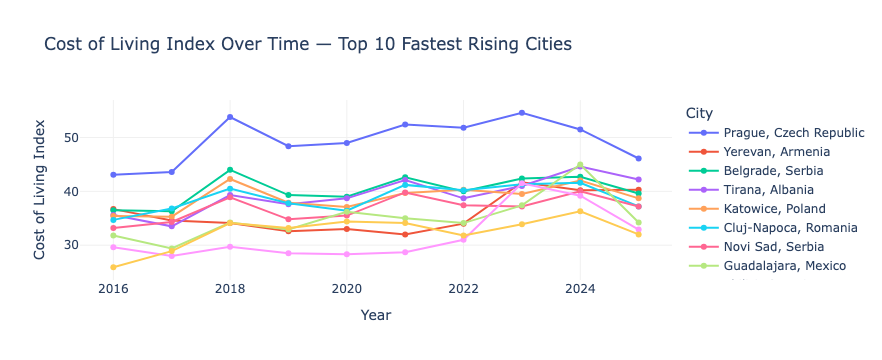

In [21]:
# Get the top 10 cities
top10_cities = top10['City'].tolist()

# Filter full dataset for those cities
top10_trend = df[df['City'].isin(top10_cities)]

# Line plot
fig = px.line(
    top10_trend,
    x='year',
    y='Cost of Living Index',
    color='City',
    title='Cost of Living Index Over Time — Top 10 Fastest Rising Cities',
    markers=True
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Cost of Living Index',
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(gridcolor='#f0f0f0'),
    yaxis=dict(gridcolor='#f0f0f0'),
)

fig.show()

,Rank,City,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,year
0,1,"Hamilton, Bermuda",132.3,120.9,126.8,128.6,120.4,118.9,2016
1,2,"Zurich, Switzerland",131.0,64.2,98.9,131.7,131.8,184.9,2016
2,3,"Basel, Switzerland",129.9,47.6,90.4,132.8,126.9,165.7,2016
3,4,"Geneva, Switzerland",129.1,74.1,102.6,124.1,130.7,181.0,2016
4,5,"Zug, Switzerland",123.4,63.3,94.5,122.6,118.0,211.3,2016
...,...,...,...,...,...,...,...,...,...
4797,323,"Lucknow (Lakhnau), India",18.8,4.0,12.2,20.0,14.6,64.2,2025
4798,324,"Karachi, Pakistan",18.7,3.1,11.8,18.0,16.2,27.8,2025
4799,325,"Lahore, Pakistan",18.4,3.2,11.6,16.6,17.7,28.0,2025
4800,326,"Alexandria, Egypt",17.9,2.5,11.1,19.8,15.7,18.9,2025


1. Which cities did rent go up the most, which remained the cheapest
2. Which cities did groceries go up the most, which remained the cheapest
3. Which cities did eating at restaurants go up the most, which remained the cheapest

In [23]:
def analyse_column(df, column, label, min_baseline=0, top_n=10):
    first_year = df[df['year'] == df['year'].min()][['City', column]].rename(columns={column: 'first'})
    last_year  = df[df['year'] == df['year'].max()][['City', column]].rename(columns={column: 'last'})
    
    merged = pd.merge(first_year, last_year, on='City').dropna()
    merged = merged[merged['first'] >= min_baseline]
    merged['pct_change'] = ((merged['last'] - merged['first']) / merged['first'] * 100).round(2)
    
    print(f'\n========== {label} ==========')
    
    print(f'\nTop {top_n} Biggest Rises:')
    print(merged.sort_values('pct_change', ascending=False).head(top_n)[['City', 'first', 'last', 'pct_change']].to_string(index=False))
    
    print(f'\nTop {top_n} Cheapest in Latest Year:')
    print(merged.sort_values('last').head(top_n)[['City', 'first', 'last', 'pct_change']].to_string(index=False))

analyse_column(df, 'Rent Index',             'Rent',        min_baseline=10)
analyse_column(df, 'Groceries Index',        'Groceries',   min_baseline=20)
analyse_column(df, 'Restaurant Price Index', 'Restaurants', min_baseline=20)


========== Rent ==========

Top 10 Biggest Rises:
                City  first  last  pct_change
    Limassol, Cyprus   14.9  34.0      128.19
    Yerevan, Armenia   10.7  18.9       76.64
      Split, Croatia   10.6  18.5       74.53
     Porto, Portugal   14.9  25.4       70.47
    Lisbon, Portugal   19.9  33.4       67.84
     Valencia, Spain   14.8  23.7       60.14
   Monterrey, Mexico   12.6  19.8       57.14
      London, Canada   20.8  32.1       54.33
     Braga, Portugal   11.3  17.4       53.98
Riyadh, Saudi Arabia   16.6  25.4       53.01

Top 10 Cheapest in Latest Year:
                  City  first  last  pct_change
      Algiers, Algeria   10.2   4.5      -55.88
          Cairo, Egypt   11.0   4.9      -55.45
        Tripoli, Libya   16.6   5.0      -69.88
   Novosibirsk, Russia   11.4   6.8      -40.35
      Curitiba, Brazil   10.4   7.3      -29.81
  Porto Alegre, Brazil   11.1   7.6      -31.53
Belo Horizonte, Brazil   10.1   7.8      -22.77
      Campinas, Brazil   1

As of 2025:
1. Top 10 highest cost of living cities
2. Top 10 Rent
3. Top 10 Groceries
4. Top 10 Restaurants

In [24]:
latest = df[df['year'] == 2025]

categories = {
    'Cost of Living Index': 'Top 10 Highest Cost of Living Cities (2025)',
    'Rent Index': 'Top 10 Highest Rent Cities (2025)',
    'Groceries Index': 'Top 10 Most Expensive Groceries (2025)',
    'Restaurant Price Index': 'Top 10 Most Expensive Restaurants (2025)',
}

for col, title in categories.items():
    print(f'\n========== {title} ==========')
    print(latest[['City', col]].sort_values(col, ascending=False).head(10).to_string(index=False))


========== Top 10 Highest Cost of Living Cities (2025) ==========
                            City  Cost of Living Index
             Zurich, Switzerland                 103.8
           Lausanne, Switzerland                 100.9
             Geneva, Switzerland                 100.7
     New York, NY, United States                 100.0
              Basel, Switzerland                  98.0
               Bern, Switzerland                  95.0
San Francisco, CA, United States                  90.5
     Honolulu, HI, United States                  86.9
              Reykjavik, Iceland                  83.7
       Boston, MA, United States                  83.7

========== Top 10 Highest Rent Cities (2025) ==========
                            City  Rent Index
     New York, NY, United States       100.0
San Francisco, CA, United States        78.0
       Boston, MA, United States        75.2
        Miami, FL, United States        68.6
    San Diego, CA, United States        67.1
 